In [1]:
pip install numpy matplotlib scipy

Bit Sequence:
[1 1 1 1 0 0 0 1 1 1 1 1 1 0 1 1 1 0 1 1]


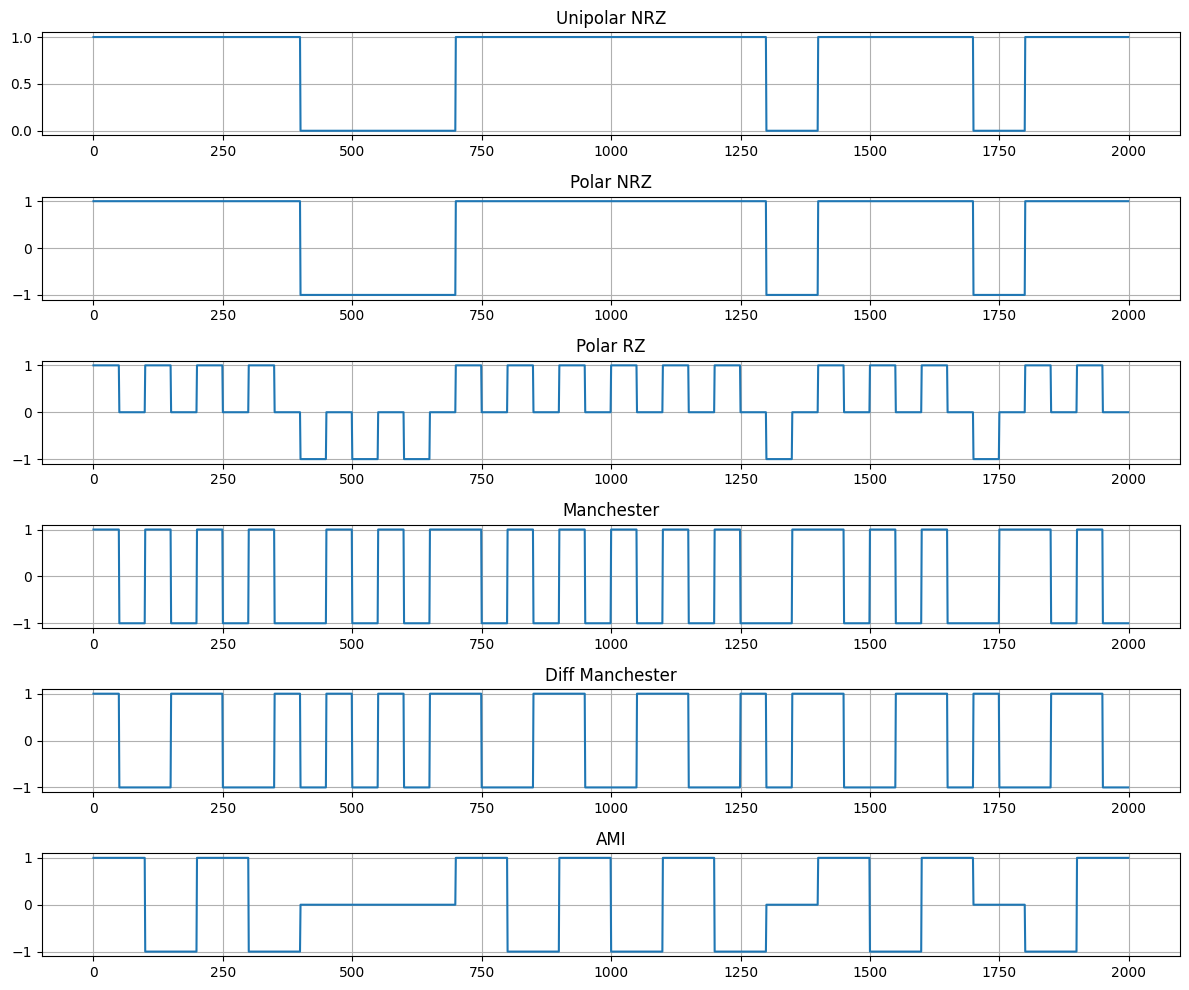

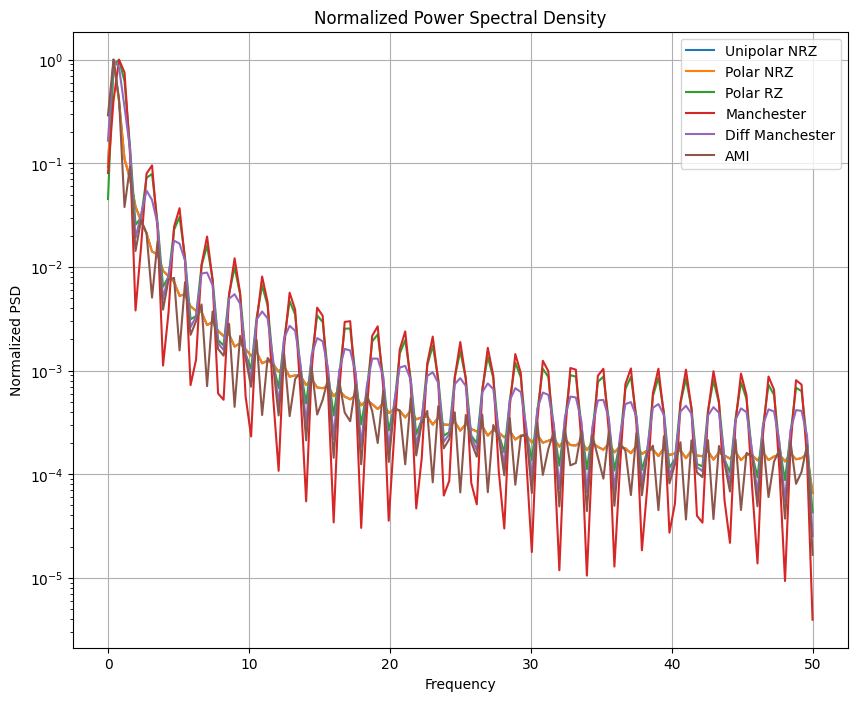

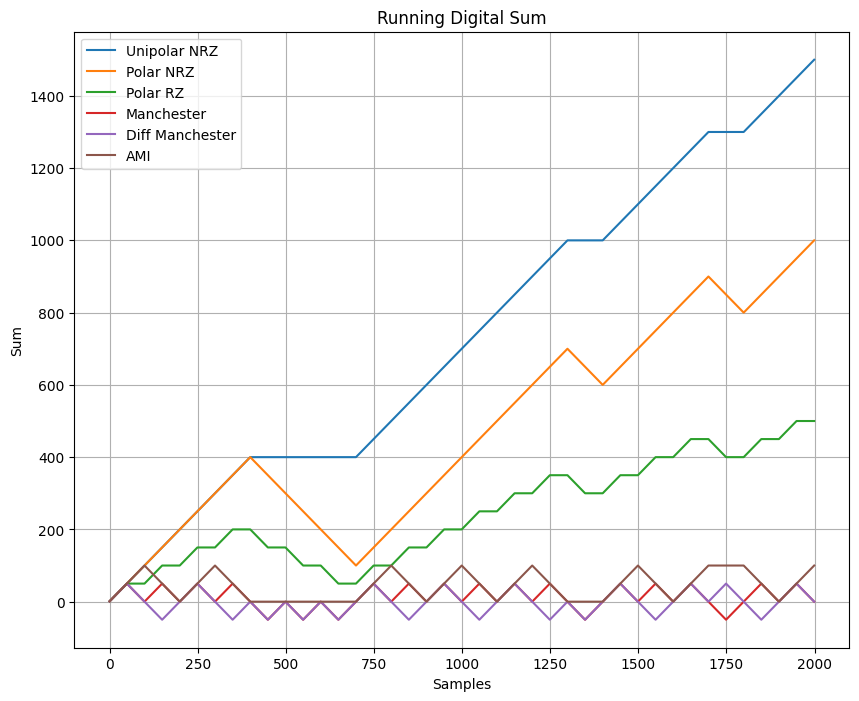

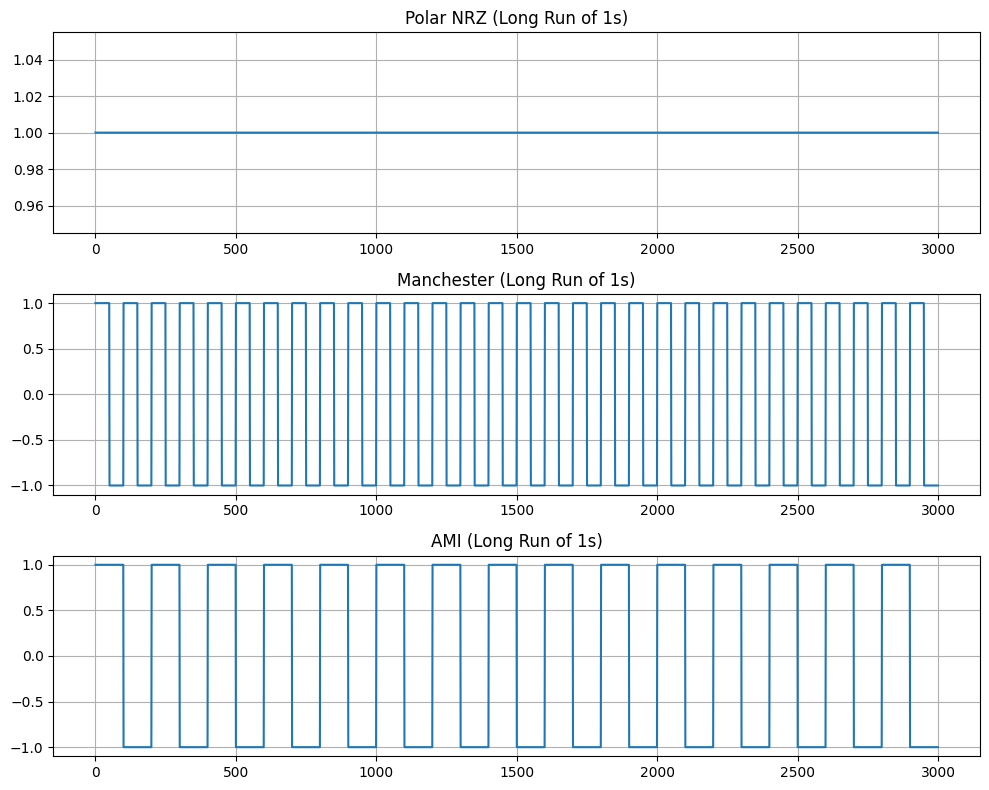


Comparison:
-----------------------------------------------
Code		DC	Bandwidth	Self Clock
-----------------------------------------------
Unipolar NRZ	High	Low		No
Polar NRZ	Medium	Low		Poor
Polar RZ	Low	Medium		Better
Manchester	None	High		Excellent
Diff Manchester	None	High		Excellent
AMI		Very Low	Medium	Good


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------
# Input Bit Sequence
# -----------------------------
bits = np.random.randint(0, 2, 20)
samples_per_bit = 100

print("Bit Sequence:")
print(bits)

# -----------------------------
# Line Coding Functions
# -----------------------------

def unipolar_nrz(bits):
    signal = []
    for b in bits:
        signal.extend([1 if b else 0] * samples_per_bit)
    return np.array(signal)

def polar_nrz(bits):
    signal = []
    for b in bits:
        signal.extend([1 if b else -1] * samples_per_bit)
    return np.array(signal)

def polar_rz(bits):
    signal = []
    half = samples_per_bit // 2
    for b in bits:
        level = 1 if b else -1
        signal.extend([level] * half)
        signal.extend([0] * half)
    return np.array(signal)

def manchester(bits):
    signal = []
    half = samples_per_bit // 2
    for b in bits:
        if b:
            signal.extend([1] * half)
            signal.extend([-1] * half)
        else:
            signal.extend([-1] * half)
            signal.extend([1] * half)
    return np.array(signal)

def differential_manchester(bits):
    signal = []
    half = samples_per_bit // 2
    current = 1

    for b in bits:
        if b == 0:
            current *= -1

        signal.extend([current] * half)
        current *= -1
        signal.extend([current] * half)

    return np.array(signal)

def ami(bits):
    signal = []
    polarity = 1

    for b in bits:
        if b:
            signal.extend([polarity] * samples_per_bit)
            polarity *= -1
        else:
            signal.extend([0] * samples_per_bit)

    return np.array(signal)

# -----------------------------
# Generate Signals
# -----------------------------
signals = {
    "Unipolar NRZ": unipolar_nrz(bits),
    "Polar NRZ": polar_nrz(bits),
    "Polar RZ": polar_rz(bits),
    "Manchester": manchester(bits),
    "Diff Manchester": differential_manchester(bits),
    "AMI": ami(bits)
}

# -----------------------------
# Plot Waveforms
# -----------------------------
plt.figure(figsize=(12,10))

for i, (name, sig) in enumerate(signals.items()):
    plt.subplot(len(signals),1,i+1)
    plt.plot(sig)
    plt.title(name)
    plt.grid(True)

plt.tight_layout()
plt.show()

# -----------------------------
# PSD using Welch Method
# -----------------------------
plt.figure(figsize=(10,8))

for name, sig in signals.items():
    f, Pxx = welch(sig, fs=samples_per_bit)
    Pxx = Pxx / np.max(Pxx)
    plt.semilogy(f, Pxx, label=name)

plt.title("Normalized Power Spectral Density")
plt.xlabel("Frequency")
plt.ylabel("Normalized PSD")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Running Digital Sum
# -----------------------------
plt.figure(figsize=(10,8))

for name, sig in signals.items():
    rds = np.cumsum(sig)
    plt.plot(rds, label=name)

plt.title("Running Digital Sum")
plt.xlabel("Samples")
plt.ylabel("Sum")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Long Run Test
# -----------------------------
long_bits = np.ones(30, dtype=int)

plt.figure(figsize=(10,8))

codes = {
    "Polar NRZ": polar_nrz(long_bits),
    "Manchester": manchester(long_bits),
    "AMI": ami(long_bits)
}

for i, (name, sig) in enumerate(codes.items()):
    plt.subplot(3,1,i+1)
    plt.plot(sig)
    plt.title(name + " (Long Run of 1s)")
    plt.grid(True)

plt.tight_layout()
plt.show()

# -----------------------------
# Comparison Table
# -----------------------------
print("\nComparison:")
print("-----------------------------------------------")
print("Code\t\tDC\tBandwidth\tSelf Clock")
print("-----------------------------------------------")
print("Unipolar NRZ\tHigh\tLow\t\tNo")
print("Polar NRZ\tMedium\tLow\t\tPoor")
print("Polar RZ\tLow\tMedium\t\tBetter")
print("Manchester\tNone\tHigh\t\tExcellent")
print("Diff Manchester\tNone\tHigh\t\tExcellent")
print("AMI\t\tVery Low\tMedium\tGood")